# House Price Prediction Model

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_validate, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
    r2_score
)

In [ ]:
RANDOM_STATE = 42
CSV_PATH = "housing.csv"          # update path for a different dataset
TARGET_COL = "median_house_value" # target column name

In [ ]:
df = pd.read_csv(CSV_PATH)

In [ ]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [ ]:
df.shape

(20640, 10)

In [ ]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()

print("Target column:", TARGET_COL)
print("Numerical columns:", num_cols)
print("Categorical columns:", cat_cols)

Target column: median_house_value
Numerical columns: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value']
Categorical columns: ['ocean_proximity']


In [ ]:
df.isnull().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,207
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


In [ ]:
# descriptive stat
df[num_cols].describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


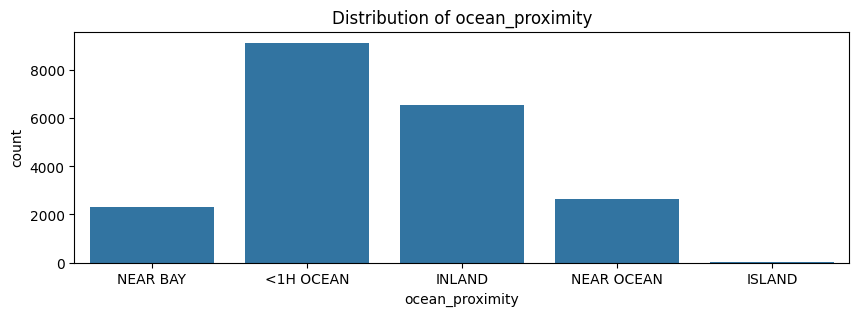

In [ ]:
# countplot for categorical columns
for col in cat_cols:
    plt.figure(figsize=(10, 3))
    sns.countplot(x=col, data=df)
    plt.title(f"Distribution of {col}")
    plt.show()

In [ ]:
for col in cat_cols:
    print(df[col].value_counts())

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64


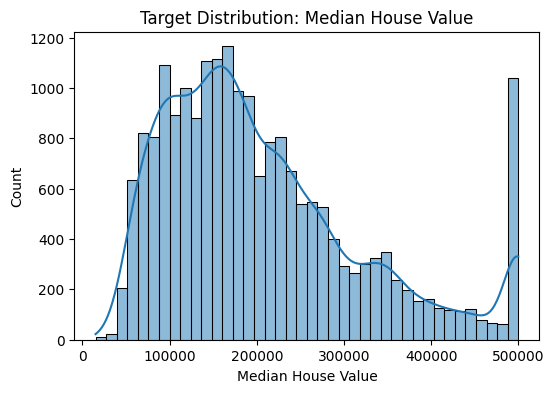

In [ ]:
# target column distribution
plt.figure(figsize=(6,4))
sns.histplot(df[TARGET_COL], bins=40, kde=True)
plt.title("Target Distribution: Median House Value")
plt.xlabel("Median House Value")
plt.show()

In [ ]:
df[TARGET_COL].value_counts()
# higher cap

,count
median_house_value,
500001.0,965
137500.0,122
162500.0,117
112500.0,103
187500.0,93
...,...
34200.0,1
46200.0,1
352000.0,1


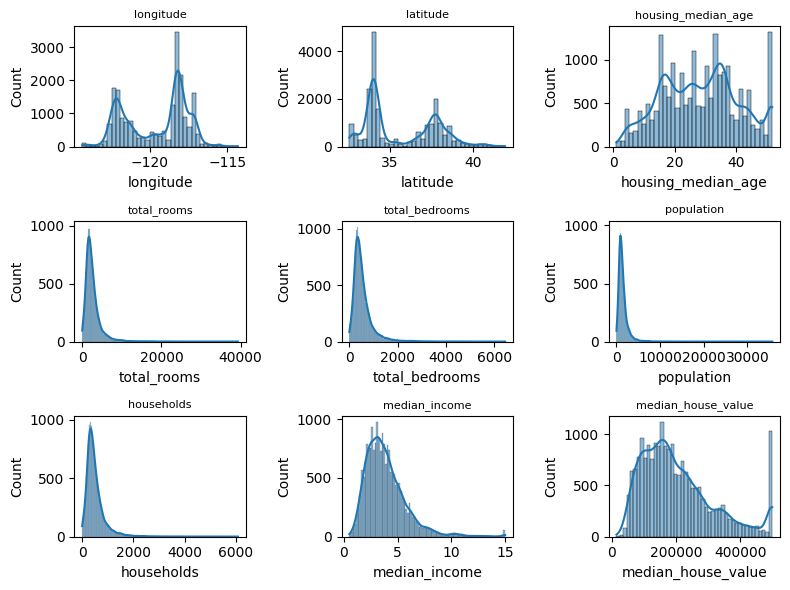

In [ ]:
# histogram plot - distribution
fig, axes = plt.subplots(3, 3, figsize=(8, 6))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(col, fontsize=8)

plt.tight_layout()
plt.show()

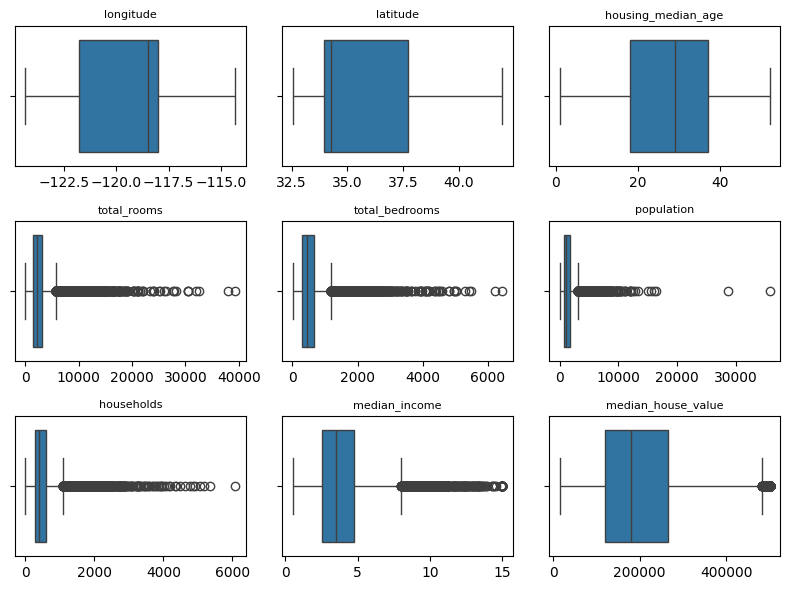

In [ ]:
# outliers analysis - boxplot
fig, axes = plt.subplots(3, 3, figsize=(8, 6))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(col, fontsize=8)
    axes[i].set_xlabel("")

plt.tight_layout()
plt.show()

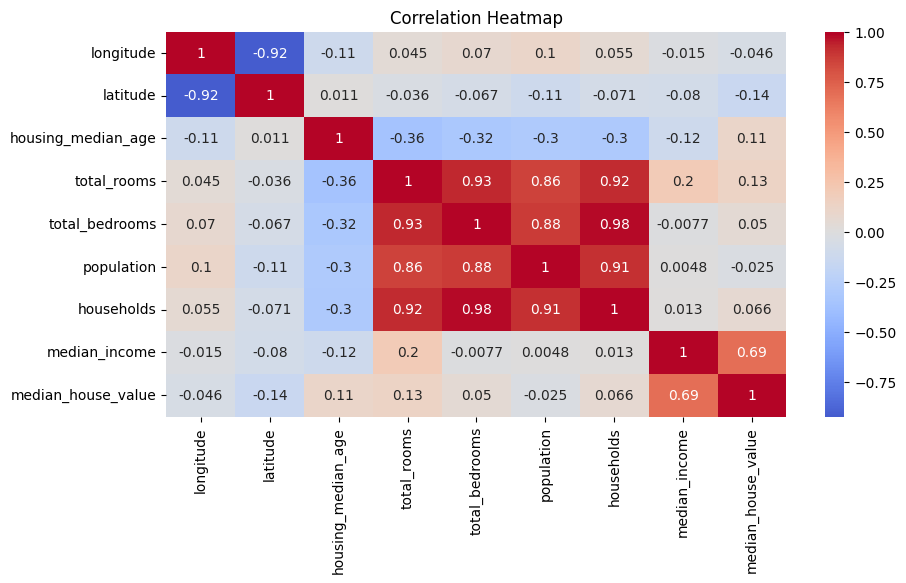

In [ ]:
# identify presence of highly correlated columns & feature relationships
plt.figure(figsize=(10, 5))
sns.heatmap(
    df[num_cols].corr(),
    annot=True,
    cmap="coolwarm",
    center=0
)
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
# Correlation with target
corr_with_target = df[num_cols].corr()[TARGET_COL].sort_values(ascending=False)
print("\nCorrelation with target:")
print(corr_with_target)


Correlation with target:
median_house_value    1.000000
median_income         0.688075
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049686
population           -0.024650
longitude            -0.045967
latitude             -0.144160
Name: median_house_value, dtype: float64


Key Insights from EDA
- Dataset has numeric + one categorical feature (ocean_proximity)
- Only total_bedrooms has missing values
- Target (median_house_value) is right-skewed and capped
- Several features show strong skew and outliers
- median_income is the strongest predictor
- High multicollinearity among room and population features


Preprocessing & Evaluation Plan
- Median imputation for missing values
- One-hot encoding for categorical feature
- Feature scaling for linear models
- Use pipelines to avoid data leakage
- Baseline model → CV model selection → hyperparameter tuning
- Primary metric: RMSE, secondary: MAE and R²
- Final evaluation only on test set




In [ ]:
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

In [ ]:
X.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,NEAR BAY


In [ ]:
y.head()

,median_house_value
0,452600.0
1,358500.0
2,352100.0
3,341300.0
4,342200.0


In [ ]:
# train test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE
)

In [ ]:
print("Train shape:", X_train.shape)

print("Test shape:", X_test.shape)

Train shape: (16512, 9)
Test shape: (4128, 9)


In [ ]:
numerical_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

print("Numerical features:", numerical_features)
print("Categorical features:", categorical_features)

# numerical features - preprocessing steps
numerical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

# categorical features - preprocessing steps
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

# preprocessing pipeline
preprocess = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

Numerical features: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income']
Categorical features: ['ocean_proximity']


In [ ]:
baseline_pipe = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", LinearRegression())
    ]
)

In [ ]:
baseline_pipe.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['longitude', 'latitude',
                                                   'housing_median_age',
                                                   'total_rooms',
                                                   'total_bedrooms',
                                                   'population', 'households',
                                                   'median_income']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['ocean_proximity'])])),
                ('model', LinearRegression())])

In [ ]:
train_baseline_pred = baseline_pipe.predict(X_train)
test_baseline_pred = baseline_pipe.predict(X_test)

In [ ]:
train_baseline_pred[:5]

array([188628.0772436 , 290379.8948687 , 250985.48476349, 146878.07878194,
       165789.41368924])

In [ ]:
y_train[:5]

,median_house_value
14196,103000.0
8267,382100.0
17445,172600.0
14265,93400.0
2271,96500.0


In [ ]:
train_baseline_rmse = root_mean_squared_error(y_train, train_baseline_pred)
train_baseline_mae = mean_absolute_error(y_train, train_baseline_pred)
train_baseline_r2 = r2_score(y_train, train_baseline_pred)

print("\n=== TRAIN BASELINE METRICS (LinearRegression) ===")
print(f"RMSE: {train_baseline_rmse:.3f}")
print(f"MAE : {train_baseline_mae:.3f}")
print(f"R2  : {train_baseline_r2:.3f}")


=== TRAIN BASELINE METRICS (LinearRegression) ===
RMSE: 68433.937
MAE : 49594.842
R2  : 0.650


In [ ]:
test_baseline_rmse = root_mean_squared_error(y_test, test_baseline_pred)
test_baseline_mae = mean_absolute_error(y_test, test_baseline_pred)
test_baseline_r2 = r2_score(y_test, test_baseline_pred)

print("\n=== TEST BASELINE METRICS (LinearRegression) ===")
print(f"RMSE: {test_baseline_rmse:.3f}")
print(f"MAE : {test_baseline_mae:.3f}")
print(f"R2  : {test_baseline_r2:.3f}")


=== TEST BASELINE METRICS (LinearRegression) ===
RMSE: 70059.193
MAE : 50670.489
R2  : 0.625


In [ ]:
# models to try
models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(random_state=RANDOM_STATE),
    "Lasso": Lasso(random_state=RANDOM_STATE, max_iter=10000),
    "RandomForest": RandomForestRegressor()
}

In [ ]:
k = 5
cv = KFold(n_splits=k, shuffle=True, random_state=RANDOM_STATE)

In [ ]:
scoring = {
    "rmse": "neg_root_mean_squared_error",
    "mae": "neg_mean_absolute_error",
    "r2": "r2"
}

In [ ]:
rows = []

for name, model in models.items():
    pipe = Pipeline(
        steps=[
            ("preprocess", preprocess),
            ("model", model)
        ]
    )
    scores = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=1)
    rows.append({
        "model": name,
        "cv_rmse": -scores["test_rmse"].mean(),
        "cv_mae": -scores["test_mae"].mean(),
        "cv_r2": scores["test_r2"].mean()
    })


# sort based on lowest rmse value
cv_results = pd.DataFrame(rows).sort_values("cv_rmse")
print("=== CV Model Comparison ===")
print(cv_results)

=== CV Model Comparison ===
              model       cv_rmse        cv_mae     cv_r2
3      RandomForest  49396.332082  32268.947390  0.817432
1             Ridge  68595.617399  49664.330927  0.647760
2             Lasso  68603.233277  49667.262611  0.647685
0  LinearRegression  68604.162955  49667.159067  0.647676


In [ ]:
cv_results

,model,cv_rmse,cv_mae,cv_r2
3,RandomForest,49396.332082,32268.947390,0.817432
1,Ridge,68595.617399,49664.330927,0.647760
2,Lasso,68603.233277,49667.262611,0.647685
0,LinearRegression,68604.162955,49667.159067,0.647676


In [ ]:
best_row = cv_results.sort_values("cv_rmse").iloc[0]

best_model_name = best_row["model"]
best_rmse = best_row["cv_rmse"]

print("Best model based on CV RMSE:")
print("Model :", best_model_name)
print("CV RMSE:", best_rmse)

Best model based on CV RMSE:
Model : RandomForest
CV RMSE: 49396.332081572924


In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_best = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", RandomForestRegressor(
            n_estimators=200,
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ]
)


In [ ]:
rf_best.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['longitude', 'latitude',
                                                   'housing_median_age',
                                                   'total_rooms',
                                                   'total_bedrooms',
                                                   'population', 'households',
                                                   'median_income']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['ocean_proximity'])])),
                ('model',
                 RandomForestRegressor(n_estimators=200, n_jobs=-1,
                                       random_state=42))])

In [ ]:
import joblib

joblib.dump(rf_best, "best_house_price_model.pkl")
print("Best model saved successfully")

Best model saved successfully
